## imports

**Make sure to run using AG kernel**

In [95]:
from alphagenome_research.model import dna_model
from alphagenome import colab_utils
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript
from alphagenome.data import ontology
from alphagenome.interpretation import ism
from alphagenome.models import dna_client
from alphagenome.models import variant_scorers
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.93'

import matplotlib.pyplot as plt
import pandas as pd
from pysam import VariantFile
from io import StringIO
from tqdm import tqdm
import os
# from dotenv import load_dotenv
from alphagenome_research.model import dna_model

pd.set_option('display.max_columns', None)




LMNA_START = 156_114_711
LMNA_END = 156_140_081
gene_symbol = "LMNA"
LMNA_INTERVAL = genome.Interval('chr1', 156_114_711, 156_140_081)

AG_DATA_PATH = '/users/PAS2905/coraalbers/ag/ag_data/'

HG38_FASTA_PATH = '/users/PAS2905/coraalbers/ag/hg38.fa'
HG38_GTF_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.annotation.gtf.gz.feather'
HG38_SPLICE_START_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.splice_sites_starts.feather'
HG38_SPLICE_END_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.splice_sites_ends.feather'

# HG38_GTF_PATH = pd.read_feather( 'https://storage.googleapis.com/alphagenome/reference/gencode/' 'hg38/gencode.v46.annotation.gtf.gz.feather' )

In [44]:
output_modalities = ['atac',	
'cage',	
'chip_histone',	
'chip_tf',	
'contact_maps',	
'dnase',	
'procap',	
'rna_seq',	
'splice_junctions',	
'splice_site_usage',	
'splice_sites']

requested_outputs = {dna_client.OutputType.ATAC,
        dna_client.OutputType.CAGE,
        dna_client.OutputType.DNASE,
        dna_client.OutputType.PROCAP,
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.SPLICE_SITES,
        dna_client.OutputType.SPLICE_SITE_USAGE,
        dna_client.OutputType.SPLICE_JUNCTIONS,
        dna_client.OutputType.CONTACT_MAPS,
        dna_client.OutputType.CHIP_HISTONE,
        dna_client.OutputType.CHIP_TF}

In [8]:
# load_dotenv()
# api_key = os.getenv("AG_API_KEY")

# dna_model = dna_client.create(api_key)

model = dna_model.create_from_huggingface( 
    'all_folds', 
    organism_settings={ 
        dna_model.Organism.HOMO_SAPIENS: dna_model.OrganismSettings( 
            fasta_path=HG38_FASTA_PATH, 
            gtf_feather_path=HG38_GTF_PATH, 
            splice_site_starts_feather_path=HG38_SPLICE_START_PATH, 
            splice_site_ends_feather_path=HG38_SPLICE_END_PATH, 
        ), dna_model.Organism.MUS_MUSCULUS: dna_model.OrganismSettings() } )

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 66664.43it/s]


In [9]:
# Load gene annotations (from GENCODE).
gtf = pd.read_feather('/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.annotation.gtf.gz.feather')

# Filter to protein-coding genes and highly supported transcripts.
gtf_transcript = gene_annotation.filter_transcript_support_level(
    gene_annotation.filter_protein_coding(gtf), ['1']
)

# Extractor for identifying transcripts in a region.
transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)

# Also define an extractor that fetches only the longest transcript per gene.
gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(
    gtf_transcript
)
longest_transcript_extractor = transcript.TranscriptExtractor(
    gtf_longest_transcript
)



In [70]:
window_bp = 1_000_000

# gene_interval = gene_annotation.get_gene_interval(gtf, gene_symbol=gene_symbol)
# region = gene_interval.pad(window_bp, window_bp)

# Define interval to make predictions for (used throughout this tutorial).
# Note that the interval width must be one of the supported sequence lengths.
# interval = LMNA_INTERVAL.resize(
#     dna_client.SEQUENCE_LENGTH_1MB
# )

# pre_interval genome.Interval('chr1', LMNA_START - 1000000, LMNA_START)
# post_interval genome.Interval('chr1', LMNA_END , LMNA_END + 1000000)

interval = LMNA_INTERVAL

# Add 1KB on either side of the gene body.
interval.resize_inplace( dna_client.SEQUENCE_LENGTH_1MB ) #interval.width + 1000)

# interval = genome.Interval('chr1', LMNA_START - 1000000, LMNA_START)
# interval = interval.resize(
#     dna_client.SEQUENCE_LENGTH_1MB
# )

print(interval)

# Define the tissues/cell-types to predict expression for.
ontology_terms = [
    'UBERON:0000948',  # heart
]

# Make predictions.
output = model.predict_interval(
    interval=interval,
    requested_outputs=requested_outputs,
    ontology_terms=ontology_terms,
)

# Extract the longest transcripts per gene for this interval.
longest_transcripts = longest_transcript_extractor.extract(interval)

chr1:155603108-156651684:.


In [71]:
CCRE_CSV = AG_DATA_PATH + "lmna_cCREs_chr1_156041767_156213024.csv"

def load_ccre_intervals(csv_path, plot_interval=None):
    ccres = pd.read_csv(csv_path, skiprows=1, names=[
        "chrom", "chromStart", "chromEnd", "name", "score", "strand",
        "thickStart", "thickEnd", "reserved", "cCRE_class",
        "DNase_maxZ", "H3K4me3_maxZ", "H3K27ac_maxZ", "CTCF_maxZ",
    ])
    intervals = [
        genome.Interval(
            chromosome=row.chrom,
            start=int(row.chromStart),
            end=int(row.chromEnd),
            name=row.name,
            info={"cCRE_class": row.cCRE_class},
        )
        for _, row in ccres.iterrows()
    ]
    if plot_interval is not None:
        intervals = [iv for iv in intervals if iv.overlaps(plot_interval)]
    return intervals, ccres


ccre_intervals, ccres_df = load_ccre_intervals(CCRE_CSV, interval)

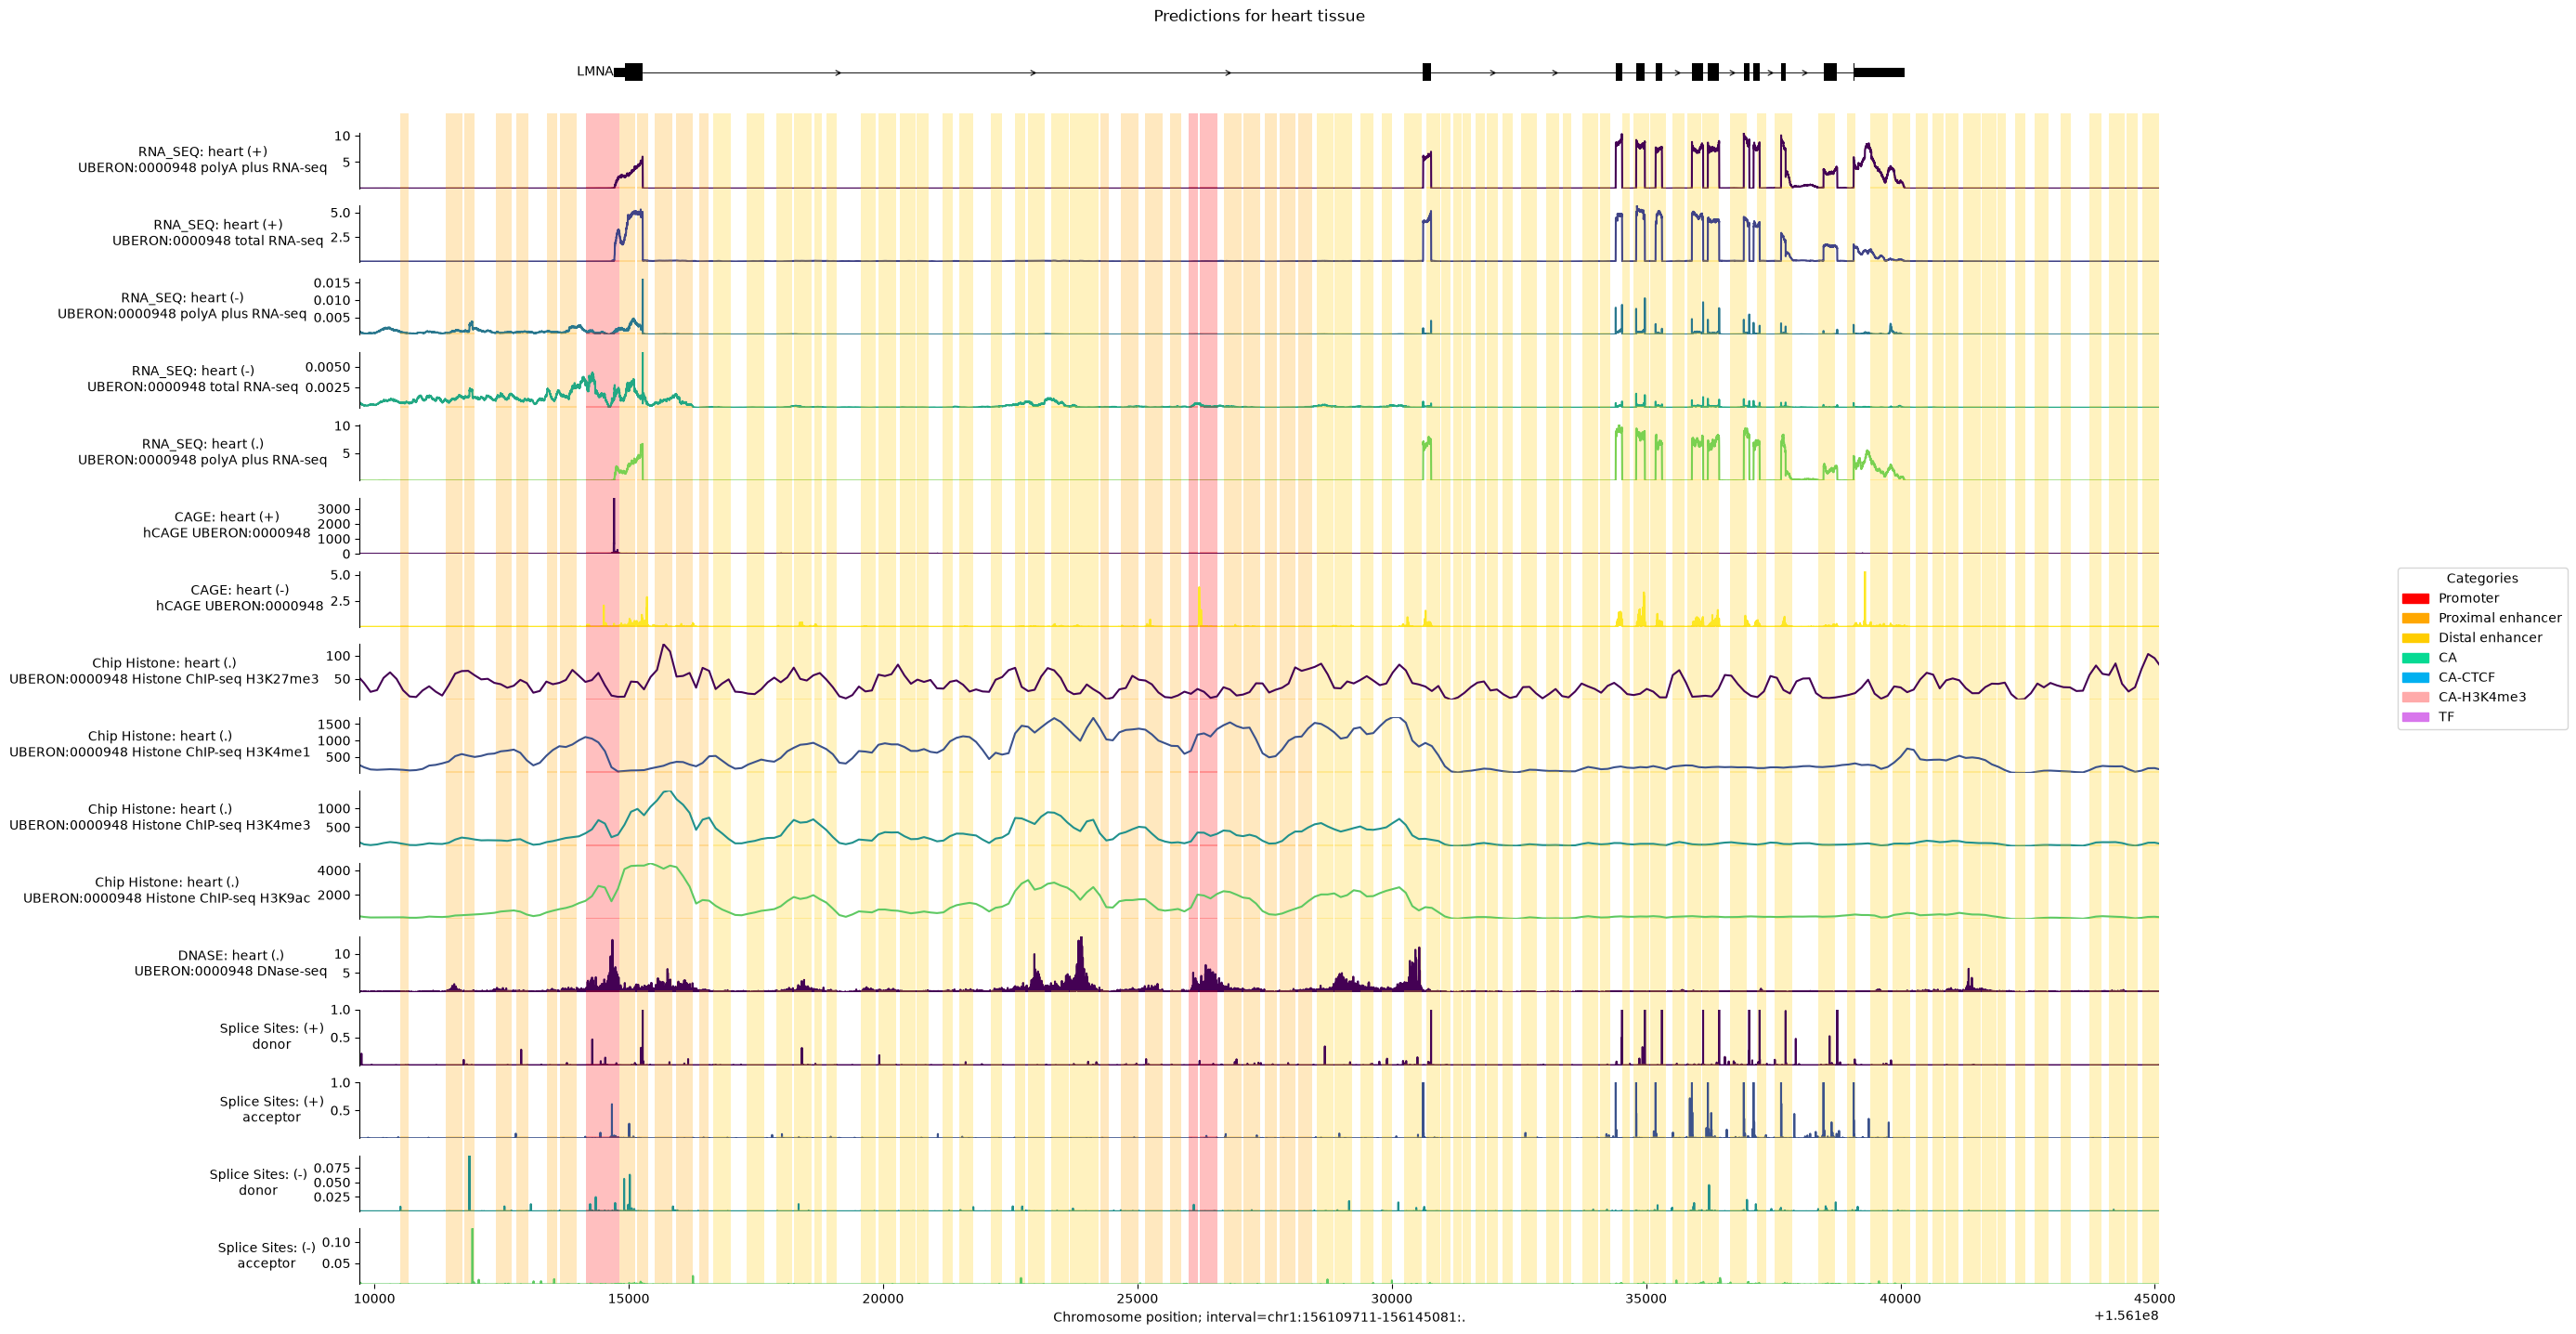

In [74]:
CCRE_COLORS = {
    "Promoter": "#FF0000",              # red          RGB(255, 0, 0)
    "Proximal enhancer": "#FFA700",     # orange       RGB(255, 167, 0)
    "Distal enhancer": "#FFCD00",       # yellow/gold  RGB(255, 205, 0)
    "CA": "#06DA93",                    # teal/green   RGB(6, 218, 147)
    "CA-CTCF": "#00B0F0",               # cyan/blue    RGB(0, 176, 240)
    "CA-H3K4me3": "#FFAAAA",            # light pink   RGB(255, 170, 170)
    "TF": "#D876EC",                    # purple       RGB(216, 118, 236)
}

ccre_colors = [
    CCRE_COLORS.get(iv.info.get("cCRE_class"), "gray")
    for iv in ccre_intervals
]
# plot_interval = interval
plot_interval = genome.Interval('chr1', LMNA_START - 5000, LMNA_END + 5000)

# Build plot.
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),
        plot_components.Tracks(
            tdata=output.rna_seq,
            ylabel_template='RNA_SEQ: {biosample_name} ({strand})\n{name}',
        ),
        plot_components.Tracks(
            tdata=output.cage,
            ylabel_template='CAGE: {biosample_name} ({strand})\n{name}',
        ),
        # Chip histone.
        plot_components.Tracks(
            tdata=output.chip_histone,
            ylabel_template='Chip Histone: {biosample_name} ({strand})\n{name}',
        ),
        # Chip tf.
        plot_components.Tracks(
            tdata=output.chip_tf,
            ylabel_template='Chip TF: {biosample_name} ({strand})\n{name}',
        ),
         # ATAC
        plot_components.Tracks(
            tdata=output.atac,
            ylabel_template='ATAC: {biosample_name} ({strand})\n{name}',
        ),
        # dnase
        plot_components.Tracks(
            tdata=output.dnase,
            ylabel_template='DNASE: {biosample_name} ({strand})\n{name}',
        ),
         # splice sites
        plot_components.Tracks(
            tdata=output.splice_sites,
            ylabel_template='Splice Sites: ({strand})\n{name}',
        ),
       
    ],
    
     annotations=[
        plot_components.IntervalAnnotation(
            ccre_intervals,
            colors=ccre_colors,
            alpha=0.25,
            use_default_labels=False,   # True if you want cCRE IDs as labels
        ),
    ],
     
    interval=plot_interval,
    fig_width=25,
    title='Predictions for heart tissue',
)

legend_handles = [
    mpatches.Patch(color=color, label=key) 
    for key, color in CCRE_COLORS.items()
]

plot.legend(handles=legend_handles, loc="center left", title="Categories",
          bbox_to_anchor=(1, 0, 0.5, 1))
plot.savefig('figs/lmna_predictions_1MB_centered_zoom_5kb_bothsides.png', dpi=300, bbox_inches="tight")


In [80]:
# plot = plot_components.plot(
#     [
#         plot_components.TranscriptAnnotation(longest_transcripts),
#         plot_components.ContactMaps(
#             tdata=output.contact_maps,
#             ylabel_template='{biosample_name}\n{name}',
#             cmap='autumn_r',
#             vmax=1.0,
#         ),
#     ],
#     interval=interval,
#     title='Predicted contact maps',
# )
# plt.show()

In [92]:
total_rna_seq = output.rna_seq.filter_tracks((output.rna_seq.metadata['Assay title'] == 'total RNA-seq').values)
total_rna_seq.values

array([[1.1742115e-05, 1.6570091e-05],
       [1.3828278e-05, 2.0027161e-05],
       [1.6093254e-05, 2.2292137e-05],
       ...,
       [3.7231445e-03, 8.2969666e-05],
       [4.6997070e-03, 1.3828278e-04],
       [5.3100586e-03, 1.8882751e-04]], shape=(1048576, 2), dtype=float32)

In [93]:
np.savez_compressed("total-rna-seq.npz", total_rna_seq.values)

In [116]:
output.atac

TrackData(values=array([], shape=(1048576, 0), dtype=float32), metadata=Empty DataFrame
Columns: [name, strand, Assay title, ontology_curie, biosample_name, biosample_type, biosample_life_stage, data_source, endedness, genetically_modified, nonzero_mean]
Index: [], resolution=1, interval=Interval(chromosome='chr1', start=155603108, end=156651684, strand='.', name=''), uns=None)

In [115]:
tissue_curie = "UBERON:0000948"

for name, tdata in [
    ("dnase", output.dnase),
    ("atac", output.atac),
    ("chip_histone", output.chip_histone),
    ("chip_tf", output.chip_tf),
    ("cage", output.cage),
]:
    print(f"\n=== {name} ===")
    if tdata is None:
        print("  output field is None (not requested / not returned)")
        continue
    print(f"  total tracks: {tdata.num_tracks}")
    print(tdata.metadata[["name", "strand", "ontology_curie"]].head(10))

    # test your filters
    filtered = select_tracks(tdata, tissue_curie=tissue_curie)
    print(f"  after tissue filter: {filtered.num_tracks if filtered else 0}")

    if name == "chip_histone":
        h3k4 = select_tracks(tdata, tissue_curie=tissue_curie, name_contains="H3K4")
        print(f"  after H3K4 filter: {h3k4.num_tracks if h3k4 else 0}")
        print("  histone names:", tdata.metadata["name"].unique()[:20])


=== dnase ===
  total tracks: 1
                         name strand  ontology_curie
220  UBERON:0000948 DNase-seq      .  UBERON:0000948
  after tissue filter: 1

=== atac ===
  total tracks: 0
Empty DataFrame
Columns: [name, strand, ontology_curie]
Index: []
  after tissue filter: 0

=== chip_histone ===
  total tracks: 4
                                         name strand  ontology_curie
794  UBERON:0000948 Histone ChIP-seq H3K27me3      .  UBERON:0000948
795   UBERON:0000948 Histone ChIP-seq H3K4me1      .  UBERON:0000948
796   UBERON:0000948 Histone ChIP-seq H3K4me3      .  UBERON:0000948
797    UBERON:0000948 Histone ChIP-seq H3K9ac      .  UBERON:0000948
  after tissue filter: 4
  after H3K4 filter: 2
  histone names: ['UBERON:0000948 Histone ChIP-seq H3K27me3'
 'UBERON:0000948 Histone ChIP-seq H3K4me1'
 'UBERON:0000948 Histone ChIP-seq H3K4me3'
 'UBERON:0000948 Histone ChIP-seq H3K9ac']

=== chip_tf ===
  total tracks: 0
Empty DataFrame
Columns: [name, strand, ontology_curie]

In [114]:
# print(output.chip_histone.metadata[["name", "strand", "ontology_curie"]])
heart = ontology.from_curie("UBERON:0000948")
output_heart = output.filter_ontology_terms([heart])
output_heart.chip_histone.metadata

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,histone_mark,data_source,endedness,genetically_modified,nonzero_mean
794,UBERON:0000948 Histone ChIP-seq H3K27me3,.,Histone ChIP-seq,UBERON:0000948,heart,tissue,embryonic,H3K27me3,encode,single,False,1.397261
795,UBERON:0000948 Histone ChIP-seq H3K4me1,.,Histone ChIP-seq,UBERON:0000948,heart,tissue,embryonic,H3K4me1,encode,single,False,2.119180
796,UBERON:0000948 Histone ChIP-seq H3K4me3,.,Histone ChIP-seq,UBERON:0000948,heart,tissue,embryonic,H3K4me3,encode,single,False,1.503649
797,UBERON:0000948 Histone ChIP-seq H3K9ac,.,Histone ChIP-seq,UBERON:0000948,heart,tissue,embryonic,H3K9ac,encode,single,False,2.471363


In [145]:
REGULATORY_MODALITIES = {
    "accessibility": [output.atac, output.dnase],
    "active_chromatin": [output.chip_histone],  # filter to H3K4me3 / H3K27ac
    "tf_binding": [output.chip_tf],
}

def select_tracks(tdata, *, tissue_curie=None, name_contains=None, strand=None):
    """Return a TrackData subset matching metadata filters."""
    if tdata is None:
        return None
    md = tdata.metadata
    mask = pd.Series(True, index=md.index)

    if tissue_curie is not None and "ontology_curie" in md.columns:
        mask &= md["ontology_curie"] == tissue_curie
    if name_contains is not None:
        mask &= md["name"].str.contains(name_contains, case=False, na=False)
    if strand is not None:
        mask &= md["strand"] == strand

    return tdata.filter_tracks(mask.to_numpy())


# collapse tracks to 1D profile
def collapse_tracks(tdata, how="max"):
    """Collapse (bins, tracks) -> (bins,) signal."""
    if tdata is None or tdata.num_tracks == 0:
        return None
    vals = tdata.values
    if how == "max":
        return vals.max(axis=1)
    if how == "mean":
        return vals.mean(axis=1)
    raise ValueError(how)


# calculate z-score 
def zscore(x):
    mu, sd = x.mean(), x.std()
    return (x - mu) / sd if sd > 0 else x * 0


# combine tracks per modality based on max z score out of all of the tracks
def combined_regulatory_profile(output, tissue_curie="UBERON:0000948"):
    profiles = []

    dnase = select_tracks(output.dnase, tissue_curie=tissue_curie)
    if dnase is not None:
        profiles.append(zscore(collapse_tracks(dnase, "max")))
        print("appending dnase track")

    atac = select_tracks(output.atac, tissue_curie=tissue_curie)
    if atac is not None:
        profiles.append(zscore(collapse_tracks(atac, "max")))
        print("appending atac track")

    h3k4me3 = select_tracks(
        output.chip_histone,
        tissue_curie=tissue_curie,
        name_contains="K4",
    )
    if h3k4me3 is not None:
        profiles.append(zscore(collapse_tracks(h3k4me3, "max")))
        print("appending h3k4me3 track")

    if not profiles:
        raise ValueError("No tracks matched filters")

    stacked = np.stack(profiles, axis=1)
    return stacked.max(axis=1)   # or .mean(axis=1) for softer consensus


# define threshold of "high scoring" as default 95th percentile
def threshold_bins(signal, method="percentile", value=95):
    if method == "percentile":
        cutoff = np.percentile(signal, value)
    elif method == "std":
        cutoff = signal.mean() + value * signal.std()
    else:
        cutoff = value
    return signal >= cutoff, cutoff


# convert continuous high scoring bins into one interval
def bins_to_intervals(signal, mask, interval, resolution):
    """Turn a boolean mask over bins into merged genomic intervals."""
    regions = []
    in_region = False
    start_bin = None

    for i, is_high in enumerate(mask):
        if is_high and not in_region:
            start_bin = i
            in_region = True
        elif not is_high and in_region:
            regions.append((start_bin, i))
            in_region = False
    if in_region:
        regions.append((start_bin, len(mask)))

    intervals = []
    for b0, b1 in regions:
        start = interval.start + b0 * resolution
        end = interval.start + b1 * resolution
        intervals.append(genome.Interval(interval.chromosome, start, end))
    return intervals


# merge intervals that are within gap# of bp 
def merge_nearby(intervals, gap=200):
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda x: x.start)
    merged = [intervals[0]]
    for iv in intervals[1:]:
        prev = merged[-1]
        if iv.start - prev.end <= gap:
            merged[-1] = genome.Interval(
                prev.chromosome, prev.start, max(prev.end, iv.end)
            )
        else:
            merged.append(iv)
    return merged


# add peak scores
def annotate_peak_scores(intervals, signal, interval, resolution):
    for iv in intervals:
        b0 = (iv.start - interval.start) // resolution
        b1 = (iv.end - interval.start) // resolution
        iv.info["max_signal"] = float(signal[b0:b1].max())
        iv.info["mean_signal"] = float(signal[b0:b1].mean())
    return sorted(intervals, key=lambda x: x.info["max_signal"], reverse=True)



def isolate_high_regulatory_regions(
    output,
    *,
    tissue_curie="UBERON:0000948",
    modalities=("dnase", "cage", "chip_histone"),
    histone_mark="H3K4",
    collapse="max",
    resolution_bp=128,
    threshold_method="percentile",
    threshold_value=95,
    min_width_bp=500,
    merge_gap_bp=200,):

    
    profiles = []
    anchor_interval = None
    anchor_resolution = resolution_bp

    def process(tdata):
        nonlocal anchor_interval
        if tdata is None:
            return
        tdata = tdata.change_resolution(resolution_bp)
        anchor_interval = tdata.interval
        profiles.append(zscore(collapse_tracks(tdata, collapse)))

    modality_map = {
        "dnase": select_tracks(output.dnase, tissue_curie=tissue_curie),
        "atac": select_tracks(output.atac, tissue_curie=tissue_curie),
        "chip_histone": select_tracks(
            output.chip_histone,
            tissue_curie=tissue_curie,
            name_contains=histone_mark,
        ),
        "chip_tf": select_tracks(output.chip_tf, tissue_curie=tissue_curie),
        "cage": select_tracks(output.cage, tissue_curie=tissue_curie),
    }

    for m in modalities:
        print(m)
        process(modality_map[m])

    print(profiles)

    # gets max score across all profiles
    signal = np.stack(profiles, axis=1).max(axis=1)
    print(signal[:10])
    mask, cutoff = threshold_bins(signal, threshold_method, threshold_value)

    intervals = bins_to_intervals(signal, mask, anchor_interval, anchor_resolution)
    
    intervals = [iv for iv in intervals if iv.width >= min_width_bp]

    # merge intervals that are within merge_gap_bp range of each other
    intervals = merge_nearby(intervals, merge_gap_bp)

    # calculate peak scores for intervals
    intervals = annotate_peak_scores(intervals, signal, anchor_interval, anchor_resolution)

    return {
        "intervals": intervals,
        "signal": signal,
        "cutoff": cutoff,
        "resolution": anchor_resolution,
        "anchor_interval": anchor_interval,
    }


In [154]:
def isolate_high_regulatory_regions_singlemod(
    output,
    *,
    tissue_curie="UBERON:0000948",
    modalities=["dnase"],
    histone_mark="H3K4",
    collapse="max",
    resolution_bp=128,
    threshold_method="percentile",
    threshold_value=95,
    min_width_bp=500,
    merge_gap_bp=200,):

    
    profiles = []
    anchor_interval = None
    anchor_resolution = resolution_bp

    def process(tdata):
        nonlocal anchor_interval
        if tdata is None:
            return
        tdata = tdata.change_resolution(resolution_bp)
        anchor_interval = tdata.interval
        profiles.append(zscore(collapse_tracks(tdata, collapse)))

    modality_map = {
        "dnase": select_tracks(output.dnase, tissue_curie=tissue_curie),
        "atac": select_tracks(output.atac, tissue_curie=tissue_curie),
        "chip_histone": select_tracks(
            output.chip_histone,
            tissue_curie=tissue_curie,
            name_contains=histone_mark,
        ),
        "chip_tf": select_tracks(output.chip_tf, tissue_curie=tissue_curie),
        "cage": select_tracks(output.cage, tissue_curie=tissue_curie),
    }

    for m in range(len(modalities)):
        modality = modalities[m]
        print(modality)
        process(modality_map[modality])

    print(profiles)

    # gets max score across all profiles
    signal = np.stack(profiles, axis=1).max(axis=1)
    print(signal[:10])
    mask, cutoff = threshold_bins(signal, threshold_method, threshold_value)

    intervals = bins_to_intervals(signal, mask, anchor_interval, anchor_resolution)
    
    intervals = [iv for iv in intervals if iv.width >= min_width_bp]

    # merge intervals that are within merge_gap_bp range of each other
    intervals = merge_nearby(intervals, merge_gap_bp)

    # calculate peak scores for intervals
    intervals = annotate_peak_scores(intervals, signal, anchor_interval, anchor_resolution)

    return {
        "intervals": intervals,
        "signal": signal,
        "cutoff": cutoff,
        "resolution": anchor_resolution,
        "anchor_interval": anchor_interval,
    }

In [164]:
result = isolate_high_regulatory_regions_singlemod(output, modalities = ['dnase'])
high_regions = result["intervals"]

# top 10 highest scoring regions
for iv in high_regions[:10]:
    print(iv, iv.info)

dnase
[array([-0.2482645 , -0.24737109, -0.24635191, ..., -0.19804838,
       -0.19325878, -0.18676636], shape=(8192,), dtype=float32)]
[-0.2482645  -0.24737109 -0.24635191 -0.24673188 -0.2640022  -0.2618509
 -0.24301015 -0.24209078 -0.23479176 -0.23431341]
chr1:156337828-156338980:. {'max_signal': 18.953271865844727, 'mean_signal': 7.191438674926758}
chr1:156052900-156055332:. {'max_signal': 17.870988845825195, 'mean_signal': 4.1241254806518555}
chr1:156456356-156457892:. {'max_signal': 17.06620979309082, 'mean_signal': 6.224229335784912}
chr1:156504484-156505636:. {'max_signal': 16.564952850341797, 'mean_signal': 5.008199214935303}
chr1:156282404-156283300:. {'max_signal': 16.45943832397461, 'mean_signal': 5.284717559814453}
chr1:156193572-156194340:. {'max_signal': 16.427486419677734, 'mean_signal': 6.976848125457764}
chr1:155934116-155935140:. {'max_signal': 16.413854598999023, 'mean_signal': 4.88978385925293}
chr1:156212644-156213668:. {'max_signal': 15.37680435180664, 'mean_signa

In [162]:
# make bed formatted df of predicted regions
# chrom / chromStart / chromEnd / name / score / strand 


pd.DataFrame([
    {
        "chrom": iv.chromosome,
        "start": iv.start,
        "end": iv.end,
        "name": f"pred_reg_{i}",
        "score": iv.info.get("max_signal"),
    }
    for i, iv in enumerate(result["intervals"])
])

pd.to_csv("

,chrom,start,end,name,score
0,chr1,156337828,156338980,pred_reg_0,18.953272
1,chr1,156052900,156055332,pred_reg_1,17.870989
2,chr1,156456356,156457892,pred_reg_2,17.066210
3,chr1,156504484,156505636,pred_reg_3,16.564953
4,chr1,156282404,156283300,pred_reg_4,16.459438
5,chr1,156193572,156194340,pred_reg_5,16.427486
6,chr1,155934116,155935140,pred_reg_6,16.413855
7,chr1,156212644,156213668,pred_reg_7,15.376804
8,chr1,156498724,156501924,pred_reg_8,13.207175
9,chr1,155609764,155610276,pred_reg_9,12.553054


In [134]:
result = isolate_high_regulatory_regions(output)
high_regions = result["intervals"]

# top 10 highest scoring regions
for iv in high_regions[:10]:
    print(iv, iv.info)

dnase
cage
chip_histone
[array([-0.2482645 , -0.24737109, -0.24635191, ..., -0.19804838,
       -0.19325878, -0.18676636], shape=(8192,), dtype=float32), array([-0.05243809, -0.0524413 , -0.0524211 , ..., -0.05215751,
       -0.0493169 , -0.0481956 ], shape=(8192,), dtype=float32), array([-0.61344665, -0.63292366, -0.63292366, ..., -0.35334793,
       -0.41989425, -0.38743263], shape=(8192,), dtype=float32)]
[-0.05243809 -0.0524413  -0.0524211  -0.05242719 -0.05245526 -0.05245207
 -0.05243465 -0.05243476 -0.05242554 -0.05242802]
chr1:156337444-156338852:. {'max_signal': 38.368141174316406, 'mean_signal': 10.240845680236816}
chr1:156282788-156283556:. {'max_signal': 19.354629516601562, 'mean_signal': 8.042437553405762}
chr1:156053668-156055588:. {'max_signal': 17.870988845825195, 'mean_signal': 5.966085910797119}
chr1:156212516-156213796:. {'max_signal': 17.824668884277344, 'mean_signal': 6.211230278015137}
chr1:156456484-156457764:. {'max_signal': 17.06620979309082, 'mean_signal': 7.32

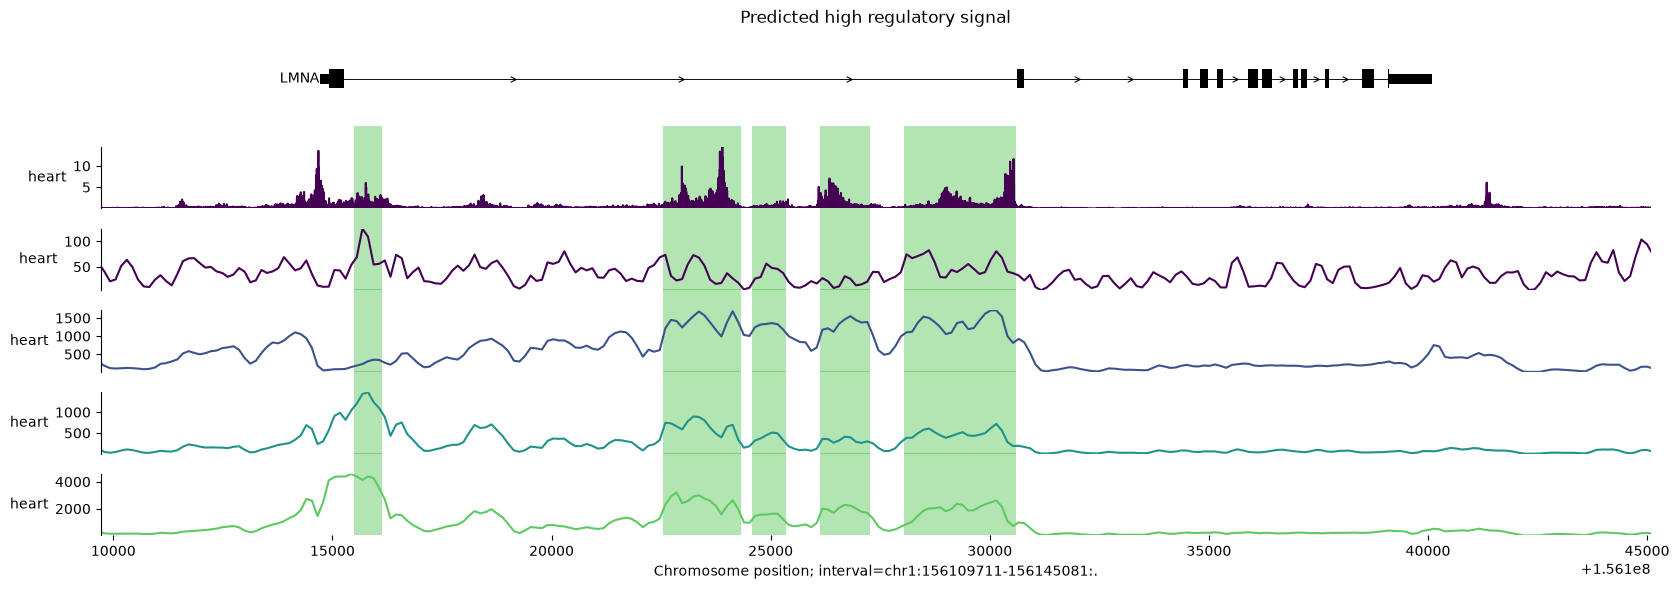

In [143]:
from alphagenome.visualization import plot_components

plot_interval = genome.Interval('chr1', LMNA_START - 5000, LMNA_END + 5000)


plot = plot_components.plot(
    [plot_components.TranscriptAnnotation(longest_transcripts),
    plot_components.Tracks(output.dnase, ylabel_template="{biosample_name}"),
     plot_components.Tracks(output.chip_histone, ylabel_template="{biosample_name}")
    ],
    interval=plot_interval,
    annotations=[
        plot_components.IntervalAnnotation(
            result["intervals"],
            alpha=0.3,
            colors=["#00AA00"] * len(result["intervals"]),
        ),
        
        # plot_components.IntervalAnnotation(
        #     ccre_intervals,
        #     colors=ccre_colors,
        #     alpha=0.25,
        #     use_default_labels=False,   # True if you want cCRE IDs as labels
        # ),
    
    ],
    title="Predicted high regulatory signal",
)

In [110]:
output.chip_histone

TrackData(values=array([[ 51.5  ,  29.875,  26.5  ,  56.   ],
       [ 61.75 ,  23.   ,  23.875,  56.5  ],
       [ 92.5  ,  16.25 ,  23.875,  54.25 ],
       ...,
       [244.   , 110.   ,  65.   , 101.   ],
       [156.   ,  89.5  ,  52.5  , 100.5  ],
       [137.   ,  99.5  ,  53.75 , 109.5  ]],
      shape=(8192, 4), dtype=float32), metadata=                                         name strand       Assay title  \
794  UBERON:0000948 Histone ChIP-seq H3K27me3      .  Histone ChIP-seq   
795   UBERON:0000948 Histone ChIP-seq H3K4me1      .  Histone ChIP-seq   
796   UBERON:0000948 Histone ChIP-seq H3K4me3      .  Histone ChIP-seq   
797    UBERON:0000948 Histone ChIP-seq H3K9ac      .  Histone ChIP-seq   

     ontology_curie biosample_name biosample_type biosample_life_stage  \
794  UBERON:0000948          heart         tissue            embryonic   
795  UBERON:0000948          heart         tissue            embryonic   
796  UBERON:0000948          heart         tissue          